In [45]:
import numpy as np
import matplotlib.pyplot as plt  

# Classes auxiliares

In [46]:
class StandardScaler:
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0) + 1e-9  

    def transform(self, X):
        return (X - self.mean) / self.std

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [47]:
def k_fold_cross_validation(model_class, X, y, k=10, seed=42, **model_params):
    n = X.shape[0]
    indices = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(indices)

    fold_size = n // k

    global_accuracies = []
    class_accuracies = []

    classes = np.unique(y)

    for i in range(k):
        start = i * fold_size
        end = start + fold_size

        test_idx = indices[start:end]
        train_idx = np.concatenate((indices[:start], indices[end:]))

        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = model_class(**model_params)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        acc_global = np.mean(y_pred.flatten() == y_test.flatten())
        global_accuracies.append(acc_global)

        acc_per_class = []
        for c in classes:
            idx = (y_test == c)
            if np.sum(idx) == 0:
                acc_per_class.append(0)
            else:
                acc_c = np.mean(y_pred[idx] == y_test[idx])
                acc_per_class.append(acc_c)

        class_accuracies.append(acc_per_class)

        print(f"Fold {i+1}")
        print(f"  Global Accuracy: {acc_global:.4f}")
        for j, c in enumerate(classes):
            print(f"  Class {c} Accuracy: {acc_per_class[j]:.4f}")
        print("-" * 30)

    class_accuracies = np.array(class_accuracies)

    print(f"Global Accuracy -> Média: {np.mean(global_accuracies):.4f} | Desvio: {np.std(global_accuracies):.4f}")

    for j, c in enumerate(classes):
        mean_c = np.mean(class_accuracies[:, j])
        std_c = np.std(class_accuracies[:, j])
        print(f"Classe {c} -> Média: {mean_c:.4f} | Desvio: {std_c:.4f}")

    return global_accuracies, class_accuracies

# Funções de plotagem

In [48]:
def plot_model_comparison(results, title="Comparação dos Modelos"):
    models = list(results.keys())
    means = [results[m]['mean'] for m in models]
    stds = [results[m]['std'] for m in models]

    plt.figure()
    plt.bar(models, means, yerr=stds, capsize=5)
    plt.title(title)
    plt.ylabel("Acurácia Média")
    plt.grid(axis='y')
    plt.show()

In [49]:
def plot_class_accuracy(class_accuracies, classes, title="Acurácia por Classe"):
    mean_per_class = np.mean(class_accuracies, axis=0)
    std_per_class = np.std(class_accuracies, axis=0)

    plt.figure()
    plt.bar(classes, mean_per_class, yerr=std_per_class, capsize=5)
    plt.title(title)
    plt.xlabel("Classes")
    plt.ylabel("Acurácia")
    plt.grid(axis='y')
    plt.show()

In [50]:
def plot_fold_distribution(global_accuracies, title="Distribuição da Acurácia"):
    plt.figure()
    plt.boxplot(global_accuracies)
    plt.title(title)
    plt.ylabel("Acurácia")
    plt.grid()
    plt.show()

# Questão 1

In [51]:
breastcance = np.loadtxt("breastcancer.csv", delimiter=",", skiprows=1)

In [52]:
X = breastcance[:, :30]

y = breastcance[:, 30]
y = y.astype(int)

### Letra A

#### Regressão logística Binária

In [53]:
class LogisticRegressionBinary:
    def __init__(self, lr=0.1, epochs=1000, **kwargs):
        self.lr = lr
        self.epochs = epochs

    def __sigmoid(self, z):
        z = np.clip(z, -500, 500)  
        return 1 / (1 + np.exp(-z))

    def __compute_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        return -np.sum(
            y_true * np.log(y_pred + 1e-9) +
            (1 - y_true) * np.log(1 - y_pred + 1e-9)
        ) / m

    def fit(self, X, y):
        m, n = X.shape
        y = y.reshape(-1, 1)

        self.W = np.zeros((n, 1))
        self.b = np.zeros((1, 1))

        for epoch in range(self.epochs):
            z = X @ self.W + self.b
            y_pred = self.__sigmoid(z)

            loss = self.__compute_loss(y, y_pred)

            dz = (y_pred - y) / m
            dW = X.T @ dz
            db = np.sum(dz, axis=0, keepdims=True)

            self.W -= self.lr * dW
            self.b -= self.lr * db

            preds = (y_pred >= 0.5).astype(int)
            acc = np.mean(preds == y)

            if epoch % 100 == 0:
                print(f"Epoch {epoch} - Loss: {loss:.4f} - Acc: {acc:.4f}")

    def predict(self, X):
        z = X @ self.W + self.b
        y_pred = self.__sigmoid(z)
        return (y_pred >= 0.5).astype(int)

    def score(self, X, y):
        y = y.reshape(-1, 1)
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

#### Análise do discriminante Gaussiano

In [54]:
class GaussianDiscriminantAnalysis:
    def fit(self, X, y):
        self.classes = np.unique(y)
        m, n = X.shape

        self.mu = {}
        self.priors = {}

        for c in self.classes:
            X_c = X[y == c]
            self.mu[c] = np.mean(X_c, axis=0)
            self.priors[c] = X_c.shape[0] / m

        sigma = np.zeros((n, n))

        for i in range(m):
            xi = X[i]
            c = y[i]
            diff = xi - self.mu[c]
            sigma += np.outer(diff, diff)

        self.sigma = sigma / m
        self.sigma_inv = np.linalg.inv(self.sigma)

    def __gaussian(self, x, mu):
        diff = x - mu
        return -0.5 * diff @ self.sigma_inv @ diff

    def predict(self, X):
        preds = []

        for x in X:
            scores = []

            for c in self.classes:
                log_prior = np.log(self.priors[c])
                log_likelihood = self.__gaussian(x, self.mu[c])
                scores.append(log_prior + log_likelihood)

            preds.append(self.classes[np.argmax(scores)])

        return np.array(preds)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

#### Naive Bayes Gaussiano

In [55]:
class GaussianNaiveBayes:
    def fit(self, X, y):
        self.classes = np.unique(y)

        self.mean = {}
        self.var = {}
        self.priors = {}

        for c in self.classes:
            X_c = X[y == c]

            self.mean[c] = np.mean(X_c, axis=0)
            self.var[c] = np.var(X_c, axis=0) + 1e-9
            self.priors[c] = X_c.shape[0] / X.shape[0]

    def __gaussian(self, x, mean, var):
        return -0.5 * np.sum(np.log(2 * np.pi * var) + ((x - mean) ** 2) / var)

    def predict(self, X):
        preds = []

        for x in X:
            scores = []

            for c in self.classes:
                log_prior = np.log(self.priors[c])
                log_likelihood = self.__gaussian(x, self.mean[c], self.var[c])
                scores.append(log_prior + log_likelihood)

            preds.append(self.classes[np.argmax(scores)])

        return np.array(preds)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

### Letra B

#### Regressão logística Binária

In [56]:
lrb = LogisticRegressionBinary(lr=0.1, epochs=1000)
global_accuracies, class_accuracies = k_fold_cross_validation(LogisticRegressionBinary, X, y, k=10, lr=0.1, epochs=1000)

Epoch 0 - Loss: 0.6931 - Acc: 0.3750
Epoch 100 - Loss: 0.0872 - Acc: 0.9883
Epoch 200 - Loss: 0.0674 - Acc: 0.9883
Epoch 300 - Loss: 0.0586 - Acc: 0.9902
Epoch 400 - Loss: 0.0531 - Acc: 0.9902
Epoch 500 - Loss: 0.0494 - Acc: 0.9922
Epoch 600 - Loss: 0.0465 - Acc: 0.9922
Epoch 700 - Loss: 0.0443 - Acc: 0.9922
Epoch 800 - Loss: 0.0424 - Acc: 0.9922
Epoch 900 - Loss: 0.0408 - Acc: 0.9922
Fold 1
  Global Accuracy: 0.9286
  Class 0 Accuracy: 0.9730
  Class 1 Accuracy: 0.8421
------------------------------
Epoch 0 - Loss: 0.6931 - Acc: 0.3594
Epoch 100 - Loss: 0.1058 - Acc: 0.9805
Epoch 200 - Loss: 0.0872 - Acc: 0.9844
Epoch 300 - Loss: 0.0791 - Acc: 0.9824
Epoch 400 - Loss: 0.0742 - Acc: 0.9844
Epoch 500 - Loss: 0.0709 - Acc: 0.9844
Epoch 600 - Loss: 0.0685 - Acc: 0.9844
Epoch 700 - Loss: 0.0666 - Acc: 0.9844
Epoch 800 - Loss: 0.0651 - Acc: 0.9844
Epoch 900 - Loss: 0.0638 - Acc: 0.9844
Fold 2
  Global Accuracy: 0.9821
  Class 0 Accuracy: 1.0000
  Class 1 Accuracy: 0.9630
-------------------

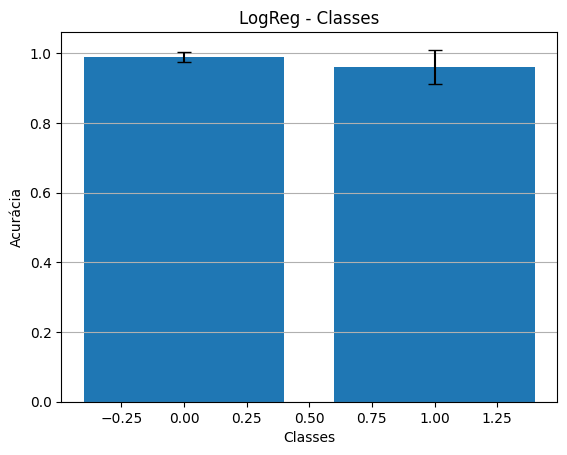

In [57]:
classes = np.unique(y)
plot_class_accuracy(class_accuracies, classes, "LogReg - Classes")

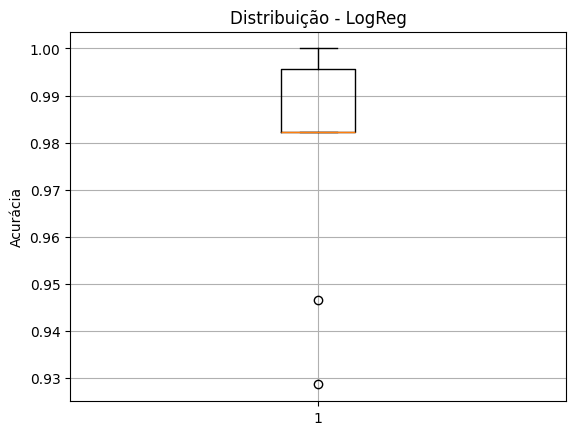

In [58]:
plot_fold_distribution(global_accuracies, "Distribuição - LogReg")

In [59]:
np.mean(global_accuracies), np.std(global_accuracies)

(np.float64(0.9785714285714284), np.float64(0.022303564279994272))

In [60]:
lrb.fit(X, y)

Epoch 0 - Loss: 0.6931 - Acc: 0.3715
Epoch 100 - Loss: 6.0568 - Acc: 0.7077
Epoch 200 - Loss: 1.9077 - Acc: 0.9067
Epoch 300 - Loss: 2.0535 - Acc: 0.8996
Epoch 400 - Loss: 1.7513 - Acc: 0.9155
Epoch 500 - Loss: 1.7513 - Acc: 0.9155
Epoch 600 - Loss: 1.7148 - Acc: 0.9173
Epoch 700 - Loss: 1.6783 - Acc: 0.9190
Epoch 800 - Loss: 5.3268 - Acc: 0.7430
Epoch 900 - Loss: 1.7513 - Acc: 0.9155


#### Análise do discriminante Gaussiano

In [61]:
gda = GaussianDiscriminantAnalysis()
global_accuracies_gda, class_accuracies_gda = k_fold_cross_validation(GaussianDiscriminantAnalysis, X, y, k=10)

Fold 1
  Global Accuracy: 0.9464
  Class 0 Accuracy: 1.0000
  Class 1 Accuracy: 0.8421
------------------------------
Fold 2
  Global Accuracy: 0.9821
  Class 0 Accuracy: 1.0000
  Class 1 Accuracy: 0.9630
------------------------------
Fold 3
  Global Accuracy: 1.0000
  Class 0 Accuracy: 1.0000
  Class 1 Accuracy: 1.0000
------------------------------
Fold 4
  Global Accuracy: 0.9821
  Class 0 Accuracy: 1.0000
  Class 1 Accuracy: 0.9500
------------------------------
Fold 5
  Global Accuracy: 0.9286
  Class 0 Accuracy: 1.0000
  Class 1 Accuracy: 0.7778
------------------------------
Fold 6
  Global Accuracy: 0.9643
  Class 0 Accuracy: 1.0000
  Class 1 Accuracy: 0.8750
------------------------------
Fold 7
  Global Accuracy: 0.9821
  Class 0 Accuracy: 1.0000
  Class 1 Accuracy: 0.9474
------------------------------
Fold 8
  Global Accuracy: 0.9107
  Class 0 Accuracy: 0.9706
  Class 1 Accuracy: 0.8182
------------------------------
Fold 9
  Global Accuracy: 0.9464
  Class 0 Accuracy: 1.0

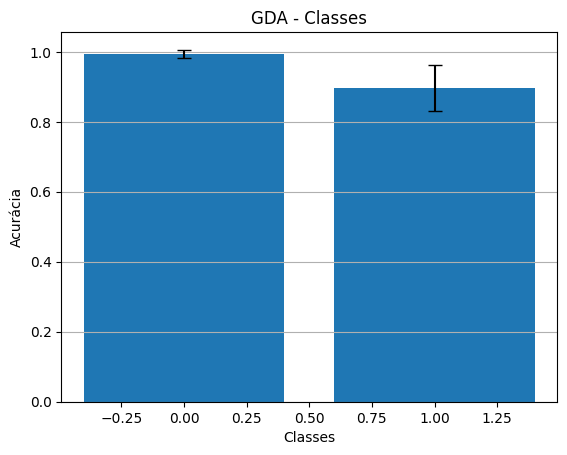

In [62]:
classes = np.unique(y)
plot_class_accuracy(class_accuracies_gda, classes, "GDA - Classes")

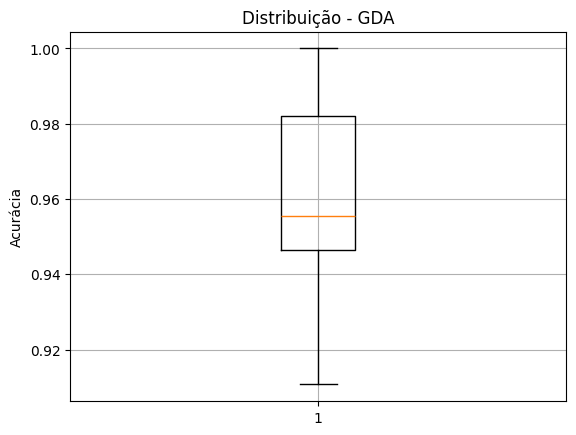

In [63]:
plot_fold_distribution(global_accuracies_gda, "Distribuição - GDA")

In [64]:
np.mean(global_accuracies_gda), np.std(global_accuracies_gda)

(np.float64(0.9589285714285714), np.float64(0.026546551334497324))

#### Naive Bayes Gaussiano

In [65]:
gnb = GaussianNaiveBayes()
global_accuracies_gnb, class_accuracies_gnb = k_fold_cross_validation(GaussianNaiveBayes, X, y, k=10)

Fold 1
  Global Accuracy: 0.8929
  Class 0 Accuracy: 0.9459
  Class 1 Accuracy: 0.7895
------------------------------
Fold 2
  Global Accuracy: 0.9643
  Class 0 Accuracy: 1.0000
  Class 1 Accuracy: 0.9259
------------------------------
Fold 3
  Global Accuracy: 0.9821
  Class 0 Accuracy: 0.9722
  Class 1 Accuracy: 1.0000
------------------------------
Fold 4
  Global Accuracy: 1.0000
  Class 0 Accuracy: 1.0000
  Class 1 Accuracy: 1.0000
------------------------------
Fold 5
  Global Accuracy: 0.9643
  Class 0 Accuracy: 0.9474
  Class 1 Accuracy: 1.0000
------------------------------
Fold 6
  Global Accuracy: 0.9107
  Class 0 Accuracy: 0.9250
  Class 1 Accuracy: 0.8750
------------------------------
Fold 7
  Global Accuracy: 0.8571
  Class 0 Accuracy: 0.8649
  Class 1 Accuracy: 0.8421
------------------------------
Fold 8
  Global Accuracy: 0.9107
  Class 0 Accuracy: 1.0000
  Class 1 Accuracy: 0.7727
------------------------------
Fold 9
  Global Accuracy: 0.9286
  Class 0 Accuracy: 0.9

In [66]:
np.mean(global_accuracies_gnb), np.std(global_accuracies_gnb)

(np.float64(0.9303571428571429), np.float64(0.043338075355398555))

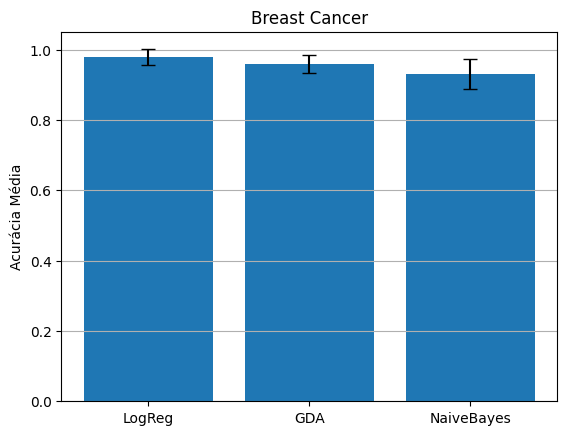

In [67]:
results = {
    "LogReg": {"mean": np.mean(global_accuracies), "std": np.std(global_accuracies)},
    "GDA": {"mean": np.mean(global_accuracies_gda), "std": np.std(global_accuracies_gda)},
    "NaiveBayes": {"mean": np.mean(global_accuracies_gnb), "std": np.std(global_accuracies_gnb)}
}

plot_model_comparison(results, "Breast Cancer")

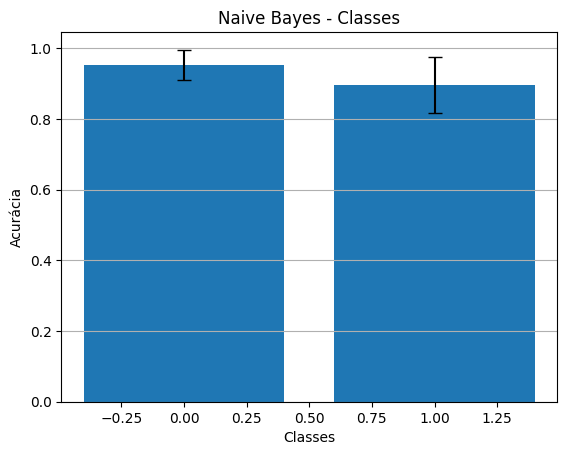

In [68]:
plot_class_accuracy(class_accuracies_gnb, classes, "Naive Bayes - Classes")

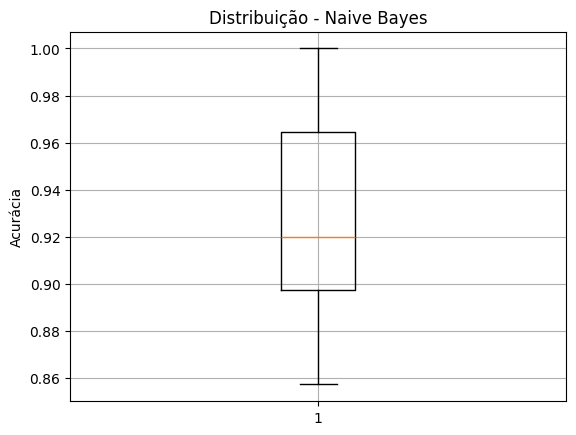

In [69]:
plot_fold_distribution(global_accuracies_gnb, "Distribuição - Naive Bayes")

# Questão 2

In [70]:
vehicle= np.loadtxt("vehicle.csv", delimiter=",", skiprows=1)

In [71]:
X = vehicle[:, :18]

y = vehicle[:, 18]

### Letra A

#### Regressão logística Binária

In [72]:
class LogisticRegressionMulticlass:
    def __init__(self, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs

    def __softmax(self, z):
        z = z - np.max(z, axis=1, keepdims=True) 
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def __one_hot(self, y, num_classes):
        one_hot = np.zeros((len(y), num_classes))
        one_hot[np.arange(len(y)), y] = 1
        return one_hot

    def __compute_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        return -np.sum(y_true * np.log(y_pred + 1e-9)) / m

    def fit(self, X, y):
        y = y.astype(int)
        m, n = X.shape
        self.classes = len(np.unique(y))

        self.W = np.zeros((n, self.classes))
        self.b = np.zeros((1, self.classes))

        y_onehot = self.__one_hot(y, self.classes)

        for epoch in range(self.epochs):

            z = X @ self.W + self.b
            y_pred = self.__softmax(z)

            loss = self.__compute_loss(y_onehot, y_pred)

            dz = (y_pred - y_onehot) / m
            dW = X.T @ dz
            db = np.sum(dz, axis=0, keepdims=True)

            self.W -= self.lr * dW
            self.b -= self.lr * db

            preds = np.argmax(y_pred, axis=1)
            acc = np.mean(preds == y)

            if epoch % 100 == 0:
                print(f"Epoch {epoch} - Loss: {loss:.4f} - Acc: {acc:.4f}")

    def predict(self, X):
        z = X @ self.W + self.b
        y_pred = self.__softmax(z)
        return np.argmax(y_pred, axis=1)

    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

### Letra B

#### Regressão logística Multiclasse

In [73]:
lrm = LogisticRegressionMulticlass(lr=0.1, epochs=1000)
global_accuracies, class_accuracies = k_fold_cross_validation(LogisticRegressionMulticlass, X, y, k=10, lr=0.1, epochs=1000)

Epoch 0 - Loss: 1.3863 - Acc: 0.2589
Epoch 100 - Loss: 0.8437 - Acc: 0.7227
Epoch 200 - Loss: 0.7329 - Acc: 0.7530
Epoch 300 - Loss: 0.6740 - Acc: 0.7674
Epoch 400 - Loss: 0.6358 - Acc: 0.7661
Epoch 500 - Loss: 0.6083 - Acc: 0.7687
Epoch 600 - Loss: 0.5872 - Acc: 0.7753
Epoch 700 - Loss: 0.5703 - Acc: 0.7740
Epoch 800 - Loss: 0.5562 - Acc: 0.7792
Epoch 900 - Loss: 0.5443 - Acc: 0.7832
Fold 1
  Global Accuracy: 0.7381
  Class 0.0 Accuracy: 0.9524
  Class 1.0 Accuracy: 0.5455
  Class 2.0 Accuracy: 0.5600
  Class 3.0 Accuracy: 1.0000
------------------------------
Epoch 0 - Loss: 1.3863 - Acc: 0.2589
Epoch 100 - Loss: 0.8409 - Acc: 0.7188
Epoch 200 - Loss: 0.7288 - Acc: 0.7516
Epoch 300 - Loss: 0.6691 - Acc: 0.7661
Epoch 400 - Loss: 0.6304 - Acc: 0.7779
Epoch 500 - Loss: 0.6025 - Acc: 0.7806
Epoch 600 - Loss: 0.5810 - Acc: 0.7845
Epoch 700 - Loss: 0.5637 - Acc: 0.7871
Epoch 800 - Loss: 0.5494 - Acc: 0.7871
Epoch 900 - Loss: 0.5373 - Acc: 0.7911
Fold 2
  Global Accuracy: 0.7143
  Class 0.0

In [74]:
np.mean(global_accuracies), np.std(global_accuracies)

(np.float64(0.7654761904761905), np.float64(0.03452380952380953))

In [75]:
lrm.fit(X, y)

Epoch 0 - Loss: 1.3863 - Acc: 0.2580
Epoch 100 - Loss: 11.3694 - Acc: 0.4473
Epoch 200 - Loss: 14.2243 - Acc: 0.3136
Epoch 300 - Loss: 14.0035 - Acc: 0.3243
Epoch 400 - Loss: 10.3541 - Acc: 0.4970
Epoch 500 - Loss: 14.4695 - Acc: 0.3018
Epoch 600 - Loss: 11.3792 - Acc: 0.4509
Epoch 700 - Loss: 12.0170 - Acc: 0.4201
Epoch 800 - Loss: 13.7024 - Acc: 0.3361
Epoch 900 - Loss: 13.5130 - Acc: 0.3479


#### Análise do discriminante Gaussiano

In [76]:
gda = GaussianDiscriminantAnalysis()
global_accuracies_gda, class_accuracies_gda = k_fold_cross_validation(GaussianDiscriminantAnalysis, X, y, k=10)

Fold 1
  Global Accuracy: 0.7738
  Class 0.0 Accuracy: 0.9524
  Class 1.0 Accuracy: 0.5909
  Class 2.0 Accuracy: 0.6400
  Class 3.0 Accuracy: 1.0000
------------------------------
Fold 2
  Global Accuracy: 0.7619
  Class 0.0 Accuracy: 0.9524
  Class 1.0 Accuracy: 0.5882
  Class 2.0 Accuracy: 0.4762
  Class 3.0 Accuracy: 0.9600
------------------------------
Fold 3
  Global Accuracy: 0.7500
  Class 0.0 Accuracy: 1.0000
  Class 1.0 Accuracy: 0.5600
  Class 2.0 Accuracy: 0.5652
  Class 3.0 Accuracy: 1.0000
------------------------------
Fold 4
  Global Accuracy: 0.7738
  Class 0.0 Accuracy: 0.8235
  Class 1.0 Accuracy: 0.6190
  Class 2.0 Accuracy: 0.7368
  Class 3.0 Accuracy: 0.8889
------------------------------
Fold 5
  Global Accuracy: 0.8452
  Class 0.0 Accuracy: 0.9667
  Class 1.0 Accuracy: 0.6667
  Class 2.0 Accuracy: 0.7222
  Class 3.0 Accuracy: 0.9444
------------------------------
Fold 6
  Global Accuracy: 0.7976
  Class 0.0 Accuracy: 0.9655
  Class 1.0 Accuracy: 0.5500
  Class 2

In [77]:
np.mean(global_accuracies_gda), np.std(global_accuracies_gda)

(np.float64(0.7797619047619048), np.float64(0.03205455242341966))

#### Naive Bayes Gaussiano

In [78]:
gnb = GaussianNaiveBayes()
global_accuracies_gnb, class_accuracies_gnb = k_fold_cross_validation(GaussianNaiveBayes, X, y, k=10)

Fold 1
  Global Accuracy: 0.4405
  Class 0.0 Accuracy: 0.0952
  Class 1.0 Accuracy: 0.4091
  Class 2.0 Accuracy: 0.4000
  Class 3.0 Accuracy: 1.0000
------------------------------
Fold 2
  Global Accuracy: 0.4167
  Class 0.0 Accuracy: 0.0476
  Class 1.0 Accuracy: 0.1765
  Class 2.0 Accuracy: 0.2857
  Class 3.0 Accuracy: 1.0000
------------------------------
Fold 3
  Global Accuracy: 0.5000
  Class 0.0 Accuracy: 0.1905
  Class 1.0 Accuracy: 0.6800
  Class 2.0 Accuracy: 0.4348
  Class 3.0 Accuracy: 0.7333
------------------------------
Fold 4
  Global Accuracy: 0.5000
  Class 0.0 Accuracy: 0.1765
  Class 1.0 Accuracy: 0.4286
  Class 2.0 Accuracy: 0.4211
  Class 3.0 Accuracy: 0.8148
------------------------------
Fold 5
  Global Accuracy: 0.4167
  Class 0.0 Accuracy: 0.1667
  Class 1.0 Accuracy: 0.3889
  Class 2.0 Accuracy: 0.3889
  Class 3.0 Accuracy: 0.8889
------------------------------
Fold 6
  Global Accuracy: 0.3810
  Class 0.0 Accuracy: 0.1724
  Class 1.0 Accuracy: 0.2500
  Class 2

Fold 8
  Global Accuracy: 0.4643
  Class 0.0 Accuracy: 0.1765
  Class 1.0 Accuracy: 0.3077
  Class 2.0 Accuracy: 0.4286
  Class 3.0 Accuracy: 0.9500
------------------------------
Fold 9
  Global Accuracy: 0.3929
  Class 0.0 Accuracy: 0.1667
  Class 1.0 Accuracy: 0.3913
  Class 2.0 Accuracy: 0.2273
  Class 3.0 Accuracy: 1.0000
------------------------------
Fold 10
  Global Accuracy: 0.5000
  Class 0.0 Accuracy: 0.2500
  Class 1.0 Accuracy: 0.4286
  Class 2.0 Accuracy: 0.4167
  Class 3.0 Accuracy: 0.9474
------------------------------
Global Accuracy -> Média: 0.4429 | Desvio: 0.0432
Classe 0.0 -> Média: 0.1664 | Desvio: 0.0549
Classe 1.0 -> Média: 0.3931 | Desvio: 0.1288
Classe 2.0 -> Média: 0.3781 | Desvio: 0.1038
Classe 3.0 -> Média: 0.8851 | Desvio: 0.1116


In [79]:
np.mean(global_accuracies_gnb), np.std(global_accuracies_gnb)

(np.float64(0.4428571428571429), np.float64(0.043186564636231085))

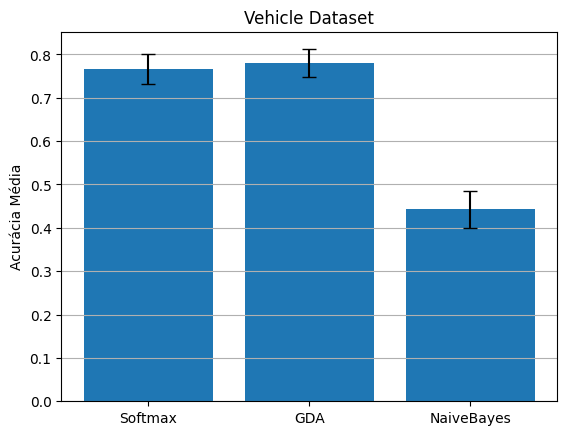

In [80]:
results = {
    "Softmax": {"mean": np.mean(global_accuracies), "std": np.std(global_accuracies)},
    "GDA": {"mean": np.mean(global_accuracies_gda), "std": np.std(global_accuracies_gda)},
    "NaiveBayes": {"mean": np.mean(global_accuracies_gnb), "std": np.std(global_accuracies_gnb)}
}

plot_model_comparison(results, "Vehicle Dataset")

In [81]:
classes = np.unique(y)

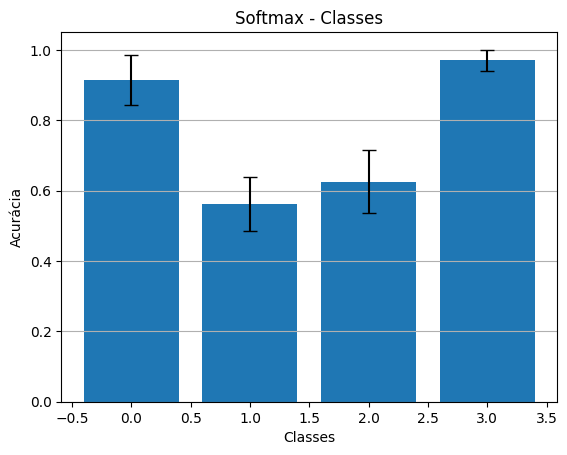

In [82]:
plot_class_accuracy(class_accuracies, classes, "Softmax - Classes")

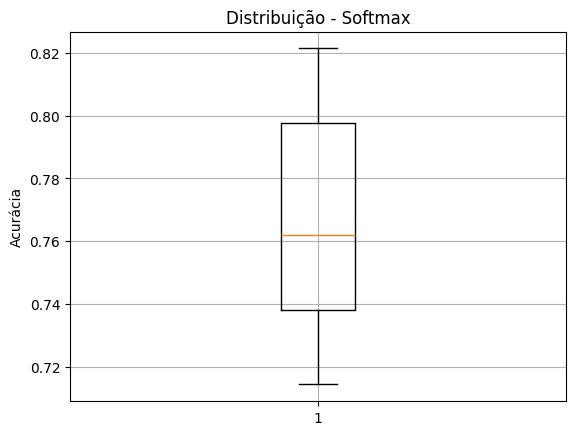

In [83]:
plot_fold_distribution(global_accuracies, "Distribuição - Softmax")

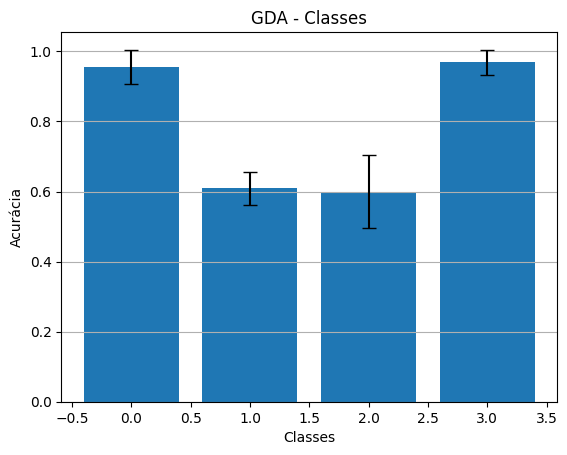

In [84]:
plot_class_accuracy(class_accuracies_gda, classes, "GDA - Classes")

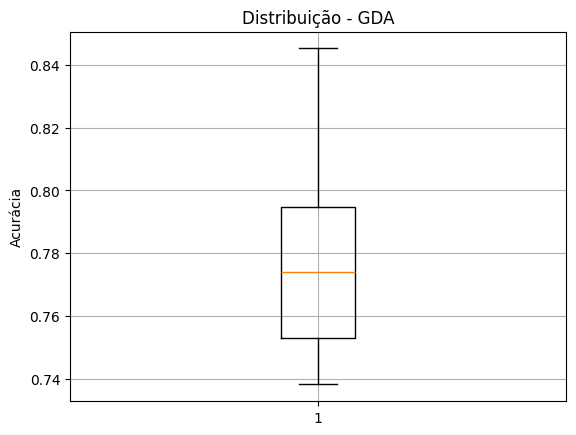

In [85]:
plot_fold_distribution(global_accuracies_gda, "Distribuição - GDA")

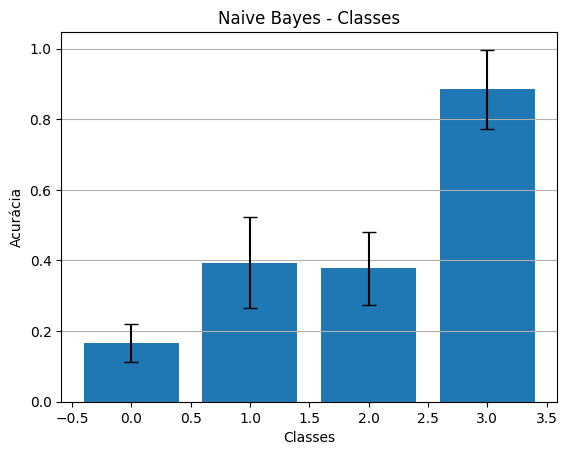

In [86]:
plot_class_accuracy(class_accuracies_gnb, classes, "Naive Bayes - Classes")

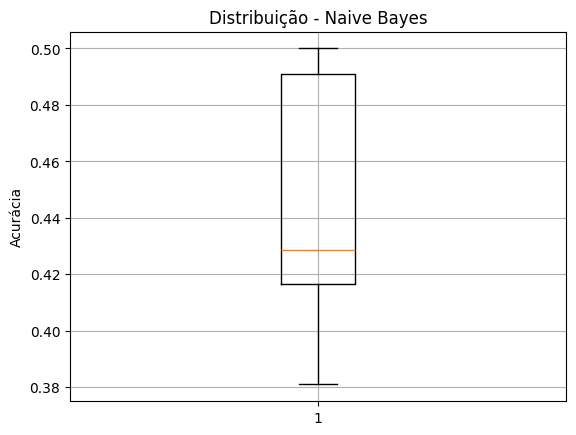

In [87]:
plot_fold_distribution(global_accuracies_gnb, "Distribuição - Naive Bayes")